# Trivial compression

Saving space (virtual or real) is often important. It is more efficient to use less space,
and it can save money.

If you are paying by the byte to store your data on a server, you may want to com
press it so that its storage costs you less.

Compression is the act of taking data and encoding it (changing its form) in such a way that it takes up less space.

Decompression is reversing the process, returning the data to its original form.

If it is more storage-efficient to compress data, then why is all data not com
pressed? 

There is a tradeoff between time and space. It takes time to compress a piece
of data and to decompress it back into its original form. Therefore, data compression
only makes sense in situations where small size is prioritized over fast execution.
Think of large files being transmitted over the internet. Compressing them makes
sense because it will take longer to transfer the files than it will to decompress them
once received. Further, the time taken to compress the files for their storage on the
original server only needs to be accounted for once.

The easiest data compression wins come about when you realize that data storage
types use more bits than are strictly required for their contents. For instance, thinking
low-level, if an unsigned integer that will never exceed 65,535 is being stored as a 64
bit unsigned integer in memory, it is being stored inefficiently. It could instead be
stored as a 16-bit unsigned integer. This would reduce the space consumption for the
actual number by 75% (16 bits instead of 64 bits). If millions of such numbers are
being stored inefficiently, it can add up to megabytes of wasted space.


Consider the nucleotides that form a gene in DNA. Each
nucleotide can only be one of four values: A, C, G, or T. (There will be more about this
in chapter 2.) Yet if the gene is stored as
a str, which can be thought of as a col
lection of Unicode characters, each
nucleotide will be represented by a char
acter, which generally requires 8 bits of
storage. In binary, just 2 bits are needed
to store a type with four possible values:
00, 01, 10, and 11 are the four different
values that can be represented by 2 bits.
If A is assigned 00, C is assigned 01, G is
assigned 10, and T is assigned 11, the
storage required for a string of nucleo
tides can be reduced by 75% (from 8 bits
to 2 bits per nucleotide).

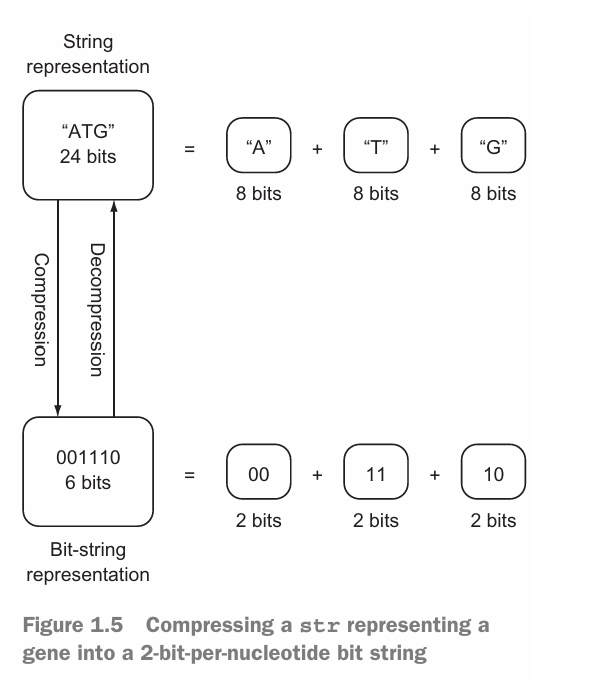

Instead of storing our nucleotides as
a str, they can be stored as a bit string
(see figure 1.5). A bit string is exactly
what it sounds like: an arbitrary-length
sequence of 1s and 0s

the Python standard library contains no off-the-shelf construct for working with bit
strings of arbitrary length.

The string of bits is stored within an int.
Because the int type in Python can be of any length, it can be used as a bit string of
any length.

In [11]:
"""
A leading underscore is used as a convention to indicate that the implementation 
of a method should not be relied on by actors outside of the class. 
(It is subject to change and should be treated as private.)
"""         

class CompressedGene:
    def __init__(self, gene: str) -> None:
        self._compress(gene)        

## Compression
###  ACGT -> 00 01 10 11 -> 100011011

In [12]:
"""The initial 1 acts as a sentinel bit so that leading zeros aren't lost when storing the result as an integer."""

def _compress(self, gene: str) -> None:
    self.bit_string: int = 1

    for nucleotide in gene.upper():
        self.bit_string <<= 2

        if nucleotide == "A":
            self.bit_string |= 0b00                 # change last two bits to 00
        
        elif nucleotide == "C":
            self.bit_string |= 0b01                 # change last two bits to 01    
        
        elif nucleotide == "G":
            self.bit_string |= 0b10                 # change last two bits to 10
        
        elif nucleotide == "T":
            self.bit_string |= 0b11                 # change last two bits to 11
        
        else:
            raise ValueError("Invalid Nucleotide: {}".format(nucleotide))

## Decompression
### 100011011 -> 00 01 10 11 -> ACGT

self.bit_string.bit_length():  It returns the number of bits needed to represent a positive integer in binary, excluding leading zeros.

In [13]:
def decompress(self) -> str:
    gene: str = ""
    for i in range(0, self.bit_string.bit_length() - 1, 2):
        bits: int = self.bit_string >> i & 0b11                 # get just 2 relevant bits

        if bits == 0b00:        # A
            gene += "A"
        
        elif bits == 0b01:      # C
            gene += "C"
        
        elif bits == 0b10:      # G
            gene += "G"
        
        elif bits == 0b11:      # T
            gene += "T"
        
        else:
            raise ValueError("Invalid Bits:{}".format(bits))
    
    return gene[::-1]


def __str__(self) -> str:                   # string representation for pretty printing
    return self.decompress()

In [14]:
class CompressedGene:
    def __init__(self, gene: str) -> None:
        self._compress(gene)
    

    def _compress(self, gene: str) -> None:
        self.bit_string: int = 1

        for nucleotide in gene.upper():
            self.bit_string <<= 2

            if nucleotide == "A":
                self.bit_string |= 0b00                
            
            elif nucleotide == "C":
                self.bit_string |= 0b01                     
            
            elif nucleotide == "G":
                self.bit_string |= 0b10                 
            
            elif nucleotide == "T":
                self.bit_string |= 0b11
            
            else:
                raise ValueError("Invalid Nucleotide: {}".format(nucleotide))
    
    def decompress(self) -> str:
        gene: str = ""
        for i in range(0, self.bit_string.bit_length() - 1, 2):
            bits: int = self.bit_string >> i & 0b11  

            if bits == 0b00:        # A
                gene += "A"
            
            elif bits == 0b01:      # C
                gene += "C"
            
            elif bits == 0b10:      # G
                gene += "G"
            
            elif bits == 0b11:      # T
                gene += "T"
            
            else:
                raise ValueError("Invalid Bits:{}".format(bits))
        
        return gene[::-1]


    def __str__(self) -> str:
        return self.decompress()


if __name__ == "__main__":
    from sys import getsizeof
    original: str = "TAGGGATTAACCGTTATATATATATAGCCATGGATCGATTATATAGGGATTAACCGTTATATATATATAGCCATGGATCGATTATA" * 100
    
    print("Original is {} bytes".format(getsizeof(original)))

    compressed: CompressedGene = CompressedGene(original)

    print("compressed is {} bytes".format(getsizeof(compressed.bit_string)))
    print(compressed)
    print("Original and Decompressed are the same: {}".format(original == compressed.decompress()))



Original is 8641 bytes
compressed is 2320 bytes
TAGGGATTAACCGTTATATATATATAGCCATGGATCGATTATATAGGGATTAACCGTTATATATATATAGCCATGGATCGATTATATAGGGATTAACCGTTATATATATATAGCCATGGATCGATTATATAGGGATTAACCGTTATATATATATAGCCATGGATCGATTATATAGGGATTAACCGTTATATATATATAGCCATGGATCGATTATATAGGGATTAACCGTTATATATATATAGCCATGGATCGATTATATAGGGATTAACCGTTATATATATATAGCCATGGATCGATTATATAGGGATTAACCGTTATATATATATAGCCATGGATCGATTATATAGGGATTAACCGTTATATATATATAGCCATGGATCGATTATATAGGGATTAACCGTTATATATATATAGCCATGGATCGATTATATAGGGATTAACCGTTATATATATATAGCCATGGATCGATTATATAGGGATTAACCGTTATATATATATAGCCATGGATCGATTATATAGGGATTAACCGTTATATATATATAGCCATGGATCGATTATATAGGGATTAACCGTTATATATATATAGCCATGGATCGATTATATAGGGATTAACCGTTATATATATATAGCCATGGATCGATTATATAGGGATTAACCGTTATATATATATAGCCATGGATCGATTATATAGGGATTAACCGTTATATATATATAGCCATGGATCGATTATATAGGGATTAACCGTTATATATATATAGCCATGGATCGATTATATAGGGATTAACCGTTATATATATATAGCCATGGATCGATTATATAGGGATTAACCGTTATATATATATAGCCATGGATCGATTATATAGGGATTAACCGTTATATATATATAGCCATGGATCGATTATATAGGGATTAACCGTTATATATATATAGCCATGGATCGATTATATAGGGA